<a href="https://colab.research.google.com/github/kurmasiddartha/sales-data-analysis/blob/main/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Better visuals
sns.set(style="whitegrid")

In [10]:
data = """Date,Region,Product,Sales,Profit
2024-01-01,South,Phone,20000,5000
2024-01-02,North,Laptop,40000,8000
2024-01-03,West,Tablet,15000,3000
2024-01-04,East,Phone,22000,6000
2024-01-05,South,Laptop,35000,7000
2024-01-06,North,Tablet,18000,4000
2024-01-07,West,Phone,25000,6500
2024-01-08,East,Laptop,42000,9000
2024-01-09,South,Tablet,16000,3500
2024-01-10,North,Phone,27000,7000
2024-01-11,West,Laptop,38000,8500
2024-01-12,East,Tablet,14000,2500
"""

In [11]:
df = pd.read_csv(StringIO(data))

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
        Date Region Product  Sales  Profit
0 2024-01-01  South   Phone  20000    5000
1 2024-01-02  North  Laptop  40000    8000
2 2024-01-03   West  Tablet  15000    3000
3 2024-01-04   East   Phone  22000    6000
4 2024-01-05  South  Laptop  35000    7000

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     12 non-null     datetime64[ns]
 1   Region   12 non-null     object        
 2   Product  12 non-null     object        
 3   Sales    12 non-null     int64         
 4   Profit   12 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 612.0+ bytes
None


In [12]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop missing values if any
df.dropna(inplace=True)

print("\nAfter Cleaning:")
print(df.isnull().sum())


Missing Values:
Date       0
Region     0
Product    0
Sales      0
Profit     0
dtype: int64

After Cleaning:
Date       0
Region     0
Product    0
Sales      0
Profit     0
dtype: int64


In [13]:
# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

print("\nUpdated Dataset:")
print(df.head())


Updated Dataset:
        Date Region Product  Sales  Profit  Month  Year  Profit_Margin
0 2024-01-01  South   Phone  20000    5000      1  2024      25.000000
1 2024-01-02  North  Laptop  40000    8000      1  2024      20.000000
2 2024-01-03   West  Tablet  15000    3000      1  2024      20.000000
3 2024-01-04   East   Phone  22000    6000      1  2024      27.272727
4 2024-01-05  South  Laptop  35000    7000      1  2024      20.000000


In [14]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("\nTotal Sales:", total_sales)
print("Total Profit:", total_profit)


Total Sales: 312000
Total Profit: 70000



Sales by Region:
Region
South    71000
East     78000
West     78000
North    85000
Name: Sales, dtype: int64


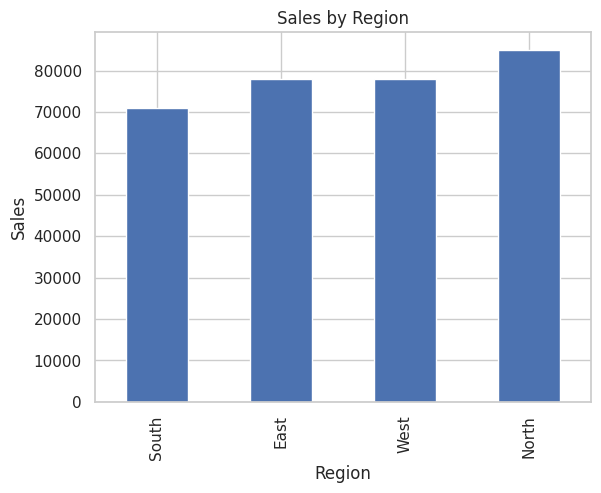

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

print("\nSales by Region:")
print(region_sales)

region_sales.plot(kind='bar', title="Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()


Profit by Region:
Region
South    15500
East     17500
West     18000
North    19000
Name: Profit, dtype: int64


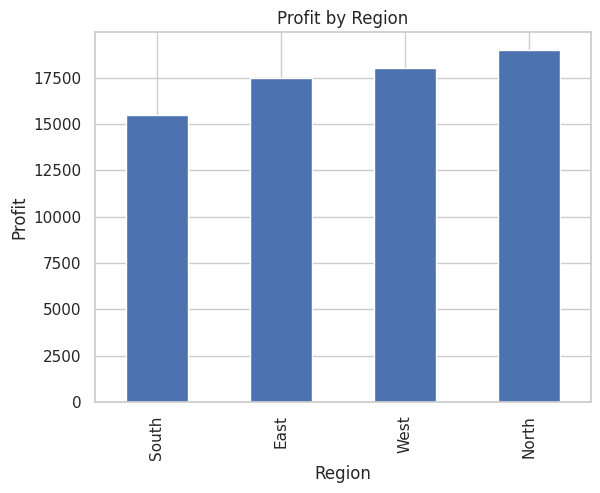

In [16]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

print("\nProfit by Region:")
print(region_profit)

region_profit.plot(kind='bar', title="Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()


Sales by Product:
Product
Laptop    155000
Phone      94000
Tablet     63000
Name: Sales, dtype: int64


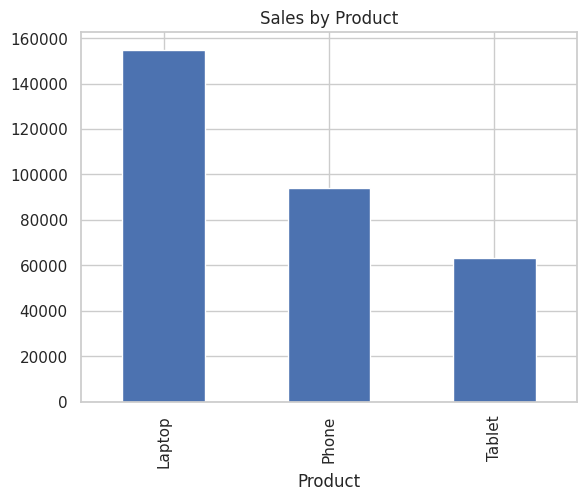

In [17]:
product_sales = df.groupby('Product')['Sales'].sum()

print("\nSales by Product:")
print(product_sales)

product_sales.plot(kind='bar', title="Sales by Product")
plt.show()


Monthly Sales:
Month
1    312000
Name: Sales, dtype: int64


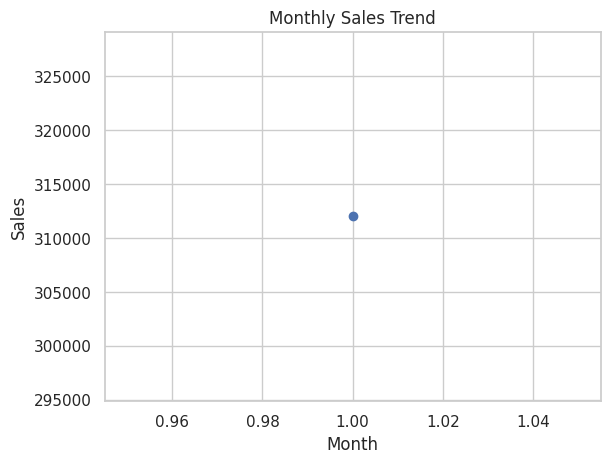

In [18]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print("\nMonthly Sales:")
print(monthly_sales)

monthly_sales.plot(marker='o', title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

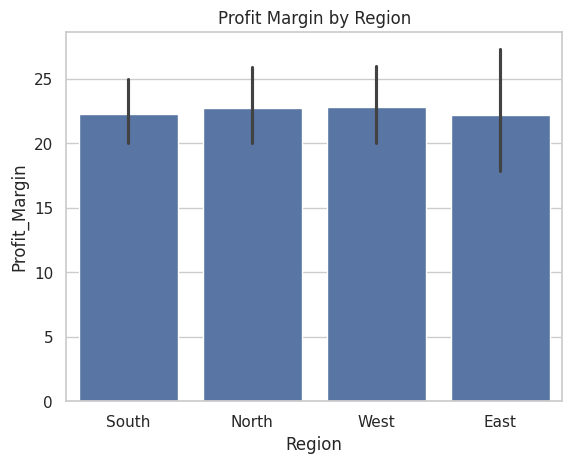

In [19]:
sns.barplot(x='Region', y='Profit_Margin', data=df)
plt.title("Profit Margin by Region")
plt.show()


Correlation Matrix:
                  Sales    Profit  Profit_Margin
Sales          1.000000  0.951880      -0.056346
Profit         0.951880  1.000000       0.245041
Profit_Margin -0.056346  0.245041       1.000000


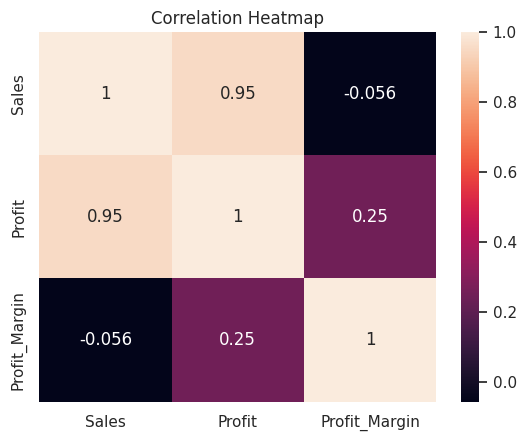

In [20]:
correlation = df[['Sales', 'Profit', 'Profit_Margin']].corr()

print("\nCorrelation Matrix:")
print(correlation)

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
print("\n--- Key Insights ---")

top_region = df.groupby('Region')['Sales'].sum().idxmax()
top_product = df.groupby('Product')['Sales'].sum().idxmax()

print(f"Top Performing Region: {top_region}")
print(f"Top Selling Product: {top_product}")
print("Sales and Profit are positively correlated.")


--- Key Insights ---
Top Performing Region: North
Top Selling Product: Laptop
Sales and Profit are positively correlated.
